In [125]:
# generating random sample from some dist-n

In [126]:
#let p(x) = e^(- x^2 /2) * math.pi

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


In [7]:
def pdf(x):
    x = float(x)
    return math.exp(-x**2 / 2) * math.pi


In [8]:
def generate_points(n,x0):
    x = x0
    res = []
    val_pred = 0
    for i in range(n):
        eps = np.random.normal(loc=0, scale=1)
        x_gen = x + eps
        val_new, val = pdf(x_gen), pdf(x)

        if val_new > val or val == 0:
            x  = x_gen
            val = val_new
        else:
            alfa = val_new/val
            u = np.random.uniform(0,1)
            if alfa > u:
                x = x_gen
                val = val_new
        res.append((x, val))
    return res
            
        

In [9]:
x0 = 0
n = 30
values = generate_points(n,x0)

In [10]:
y_vals = [val[1] for val in values]

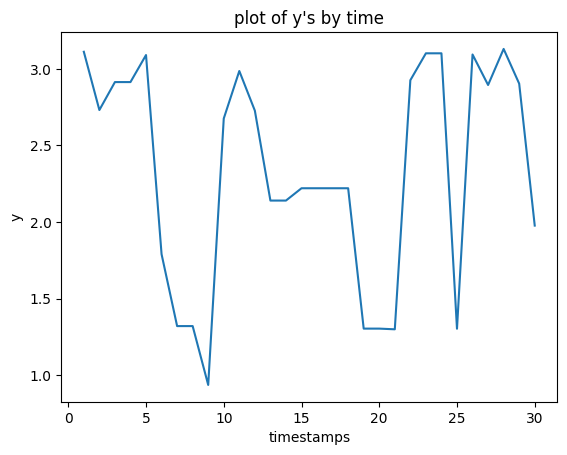

In [11]:
plt.title("plot of y's by time")
plt.plot(range(1, len(y_vals)+1), y_vals)
plt.xlabel("timestamps")
plt.ylabel("y")
plt.show()

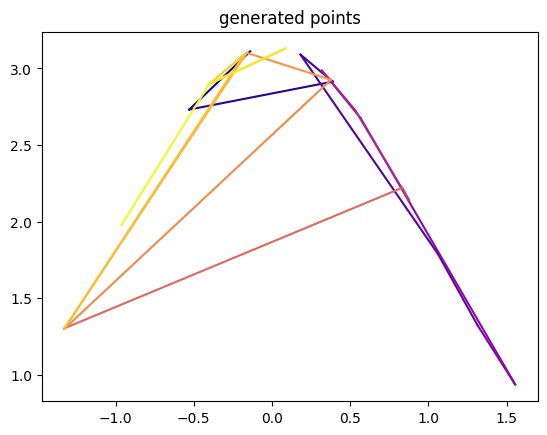

In [12]:
plt.title("generated points")
x_vals = [val[0] for val in values]

colors = cm.plasma(np.linspace(0, 1, len(values) - 1))

for i in range(len(values) - 1):
    plt.plot(x_vals[i:i+2], y_vals[i:i+2], color=colors[i])

plt.show()

In [13]:
# what if we add impuilse ? Hamiltonian algo

In [14]:
impulse = np.random.normal(loc=0, scale=1)

In [83]:
L = 20
eps = 0.1
v_next = np.random.normal(loc=0, scale=1)
v_curr = 0
pos_curr = 0
N_samples = 1000

In [84]:
# log(π * exp(-x²/2)) = log(π) - x²/2
# dpdf/dx = -x

def logpdf_deriv(x):
    return x

In [85]:
v_next = v_curr - (eps/2) * logpdf_deriv(pos_curr)
pos_next = pos_curr + eps * v_next


In [95]:
coordinates = []
v_curr = np.random.normal(loc=0, scale=1)

for _ in range(N_samples):
    v_curr = np.random.normal(loc=0, scale=1)
    pos_start = pos_curr
    v_start = v_curr
    
    pos_next = pos_curr
    v_next = v_curr
    for i in range(L):
        v_next = v_curr - (eps/2) * logpdf_deriv(pos_next)
        pos_next = pos_curr + eps * v_next
        v_next = v_curr - (eps/2) * logpdf_deriv(pos_next)

    hml_curr = (pos_start**2)/2 + (v_start**2)/2 
    hml_next = (pos_next**2)/2 + (v_next**2)/2 
    alfa = min(1, math.exp(float(hml_curr-hml_next)))
    u = np.random.uniform(0,1)
    if alfa > u:
        pos_curr = pos_next
    
    coordinates.append((pos_curr,pdf(pos_curr)))

In [103]:
len(coordinates)

1000

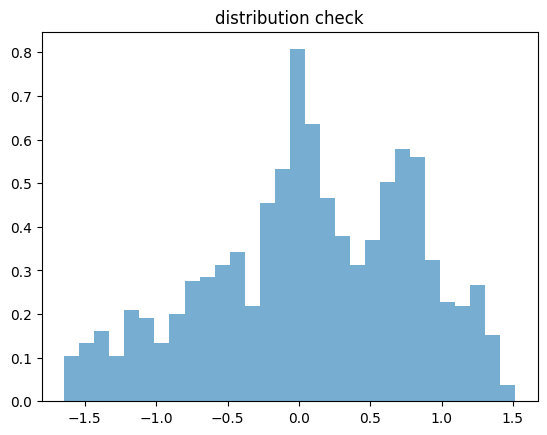

In [97]:
x_coords = [coord[0] for coord in coordinates]
y_coords = [coord[1] for coord in coordinates]

plt.hist(x_coords, bins=30, density=True, alpha=0.6)
plt.title("distribution check")
plt.show()

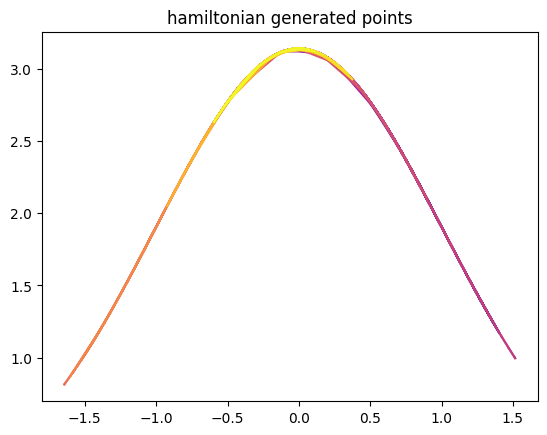

In [100]:
plt.title("hamiltonian generated points")

colors = cm.plasma(np.linspace(0, 1, len(coordinates) - 1))

for i in range(len(coordinates) - 1):
    plt.plot(x_coords[i:i+2], y_coords[i:i+2], color=colors[i])

plt.show()